# Exercise 1: Finite-precision arithmetic


# Part_1
 A 64 bits word size is commonly referred to as double precision,We would like to know: what is the roundoff error, what is the largest number, and what is the smallest number that can be represented in the computer?


In [14]:
import sys
sys.float_info

sys.float_info(max=1.7976931348623157e+308, max_exp=1024, max_10_exp=308, min=2.2250738585072014e-308, min_exp=-1021, min_10_exp=-307, dig=15, mant_dig=53, epsilon=2.220446049250313e-16, radix=2, rounds=1)

max = 1.7976931348623157e+308
min = 2.2250738585072014e-308
epsilon = 2.220446049250313e-16


# Part_2  
0.125 = 125/1000 = 1/8 =1/2^3 a good binary 0.001
and 0.25 = 1/4 = 1/2^2 also can write in binary 0.01
0.125+ 0.25 = 0.001 + 0.010 = 0.011
1/4 + 1/8 = 3/8=0.375
But!
0.1 = 1/10 =1/(2\*5)its representation keeps going forever computer cannot store infinite many digits so it cuts it down.same as 0.2
so 0.1 +0.2 = 0.300000004
and therefore 0.1+0.2==0.3 is found FALSE.


# Part_3
No we wont use == as it can come out false even though it isnt and it comes out false dure to a tiny difference. we can use math.isclose()


In [15]:
import math

a = 0.1 + 0.2
b = 0.3

print(a == b)
print(math.isclose(a, b))

False
True


# Exercise 2: Get up to speed with NumPy


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Exercise3: Build finite-difference tools


## Part 1


In [17]:
def damped_angle(t, A=0.6, gamma=0.05, omega0=np.pi):
    return A*np.exp(-gamma*t)*np.cos(omega0*t)

In [18]:
def damped_velocity(t, A=0.6, gamma=0.05, omega0=np.pi):
    return -A*np.exp(-gamma*t) * (gamma*np.cos(omega0*t) + omega0*np.sin(omega0*t))

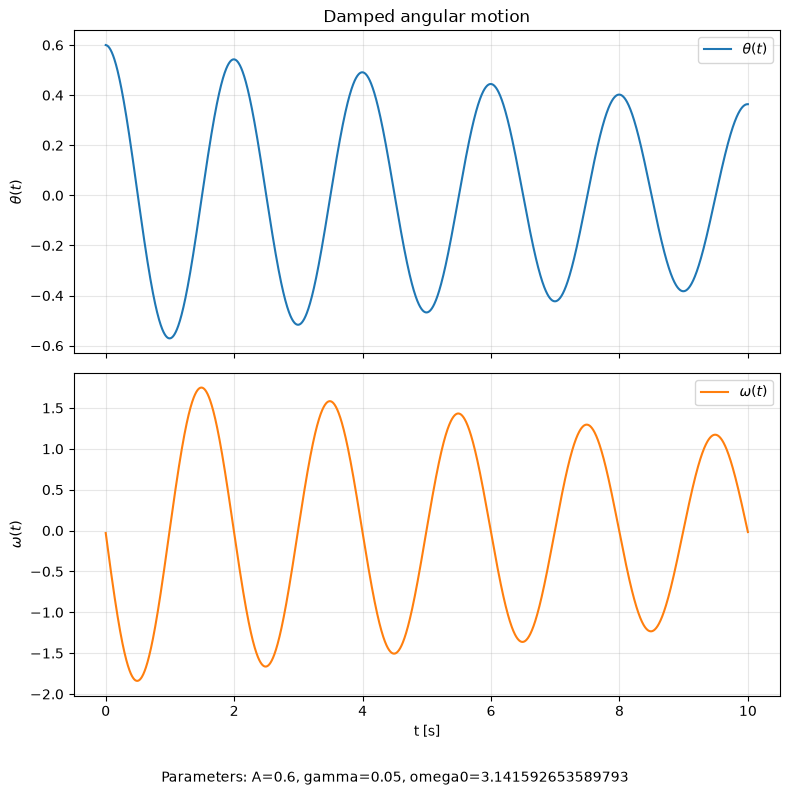

In [19]:
A = 0.6
gamma = 0.05
omega0 = np.pi
t = np.linspace(0, 10, 2000)

theta = A * np.exp(-gamma * t) * np.cos(omega0 * t)
omega = damped_velocity(t, A=A, gamma=gamma, omega0=omega0)

fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

axes[0].plot(t, theta, label=r'$\theta(t)$')
axes[0].set_ylabel(r'$\theta(t)$')
axes[0].set_title(r'Damped angular motion')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(t, omega, label=r'$\omega(t)$', color='C1')
axes[1].set_xlabel('t [s]')
axes[1].set_ylabel(r'$\omega(t)$')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.text(0.5, 0.02,
         f'Parameters: A={A}, gamma={gamma}, omega0={np.pi}',
         ha='center', va='center', fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

## Part 2


In [20]:
def forward_diff(y,h):
    y = np.asarray(y, dtype=float)
    return (y[1:] - y[:-1]) / h

In [21]:
def central_diff(y, h):
    y = np.asarray(y, dtype=float)
    return (y[2:] - y[:-2]) / (2 * h)


## Part 3


In [22]:
def derivative_at(f, x, h, method, *args, **kwargs):
    if method is forward_diff:
        values = np.array([
            f(x, *args, **kwargs),
            f(x + h, *args, **kwargs)
        ], dtype=float)
        return method(values, h)[0]

    values = np.array([
        f(x - h, *args, **kwargs),
        f(x, *args, **kwargs),
        f(x + h, *args, **kwargs)
    ], dtype=float)
    return method(values, h)[0]



In [23]:
print(f"Forward differentiated ω(0.8) = {derivative_at(damped_angle, 0.8, 1e-2, forward_diff, A=A, gamma=gamma, omega0=omega0)}")
print(f"Central differentiated ω(0.8) = {derivative_at(damped_angle, 0.8, 1e-2, central_diff, A=A, gamma=gamma, omega0=omega0)}")
print(f"Analytical expression ω(0.8) = {damped_velocity(0.8, A=A, gamma=gamma, omega0=omega0)}")

Forward differentiated ω(0.8) = -1.0174842585012278
Central differentiated ω(0.8) = -1.041023486202114
Analytical expression ω(0.8) = -1.0411869432307717


The result here shows that out of the two method of numerical differentiation, the central differentiation method is closer and more accurate than forward differentiation. Some of the error however is that $h$ is somewhat large which is also why while central differentiation is the more accurate one here it is only accurate up to the third decimal place


In [24]:
print(f"Central differentiated ω(0.8) = {derivative_at(damped_angle, 0.8, 1e-2, central_diff, A=2, gamma=gamma, omega0=0)}")
print(f"Analytical expression ω(0.8) = {damped_velocity(0.8, A=2, gamma=gamma, omega0=0)}")

Central differentiated ω(0.8) = -0.0960789479185209
Analytical expression ω(0.8) = -0.09607894391523232


This last codesnippet here is to test the extra arguments of the **derivative_at** function. To test this we put in $A = 2$ and $\omega_0 = 0$. And to verify that we get the same result, the same changes were put into the **damped_velocity** function


## Part 4


<h1> Exercise 4: Automatic for the people </h1>


<h3>4.1 A small class first</h1>


In [25]:
import numpy as np
class Point:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def distance_from_origin(self):
        return np.sqrt(self.x**2 + self.y**2)

    def move(self, dx, dy):
        self.x += dx
        self.y += dy

point1 = Point(1,1)
point2 = Point(2,2)

point1.distance_from_origin()
point2.distance_from_origin()

point2.move(2,2)
print(point2.x,point2.y)

4 4


The class holds the data inside Point as x and y, and the operations that keep the class together are distance_from_origin which calculates distance from point to (0,0) and move which updates the coordinates of the point.


<h3>  4.2 A specialized application: automatic differentiation </h1>


In [26]:
class Dual:
    """Store a function value and its derivative."""
    def __init__(self, value, derivative=0.0):
        self.value = value
        self.derivative = derivative
        
    def __repr__(self):
        return f"Dual(value={self.value}, derivative={self.derivative})"

x = Dual(3, 1)
c = Dual(3)
print(x,c)

Dual(value=3, derivative=1) Dual(value=3, derivative=0.0)


x = Dual(3, 1) specifically puts 1 as the derivative to x, because the **init** method takes a value and the derivative. Since c = Dual(3) only gets passed a value, it automatically assigns the default derivative value of 0,0. Additionally x represents a variable whose derivative is $(\frac{dx}{dx} = 1)$ while c is just a constant whose derivative is 0

The data stored inside each Dual object is: self.value and self.derivative


<h3>  4.3 Addition and subtraction </h1>


In [27]:
class Dual:
    """Store a function value and its derivative."""
    def __init__(self, value, derivative=0.0):
        self.value = value
        self.derivative = derivative
        
    def __repr__(self):
        return f"Dual(value={self.value}, derivative={self.derivative})"
    
    def __add__(self, other):
        return Dual(self.value + other.value, self.derivative + other.derivative)
    
    def __sub__(self, other):
        return Dual(self.value - other.value, self.derivative - other.derivative)

    def __neg__(self):
        return Dual(self.value * (-1), self.derivative * (-1))

u = Dual(1,2)
v = Dual(3,4)
print(u+v)
print(u-v)
print(-u)


Dual(value=4, derivative=6)
Dual(value=-2, derivative=-2)
Dual(value=-1, derivative=-2)


<h3>  4.4 Multiplication and division </h1>


In [28]:
class Dual:
    """Store a function value and its derivative."""
    def __init__(self, value, derivative=0.0):
        self.value = value
        self.derivative = derivative

    def __add__(self, other):
        return Dual(self.value + other.value, self.derivative + other.derivative)

    def __mul__(self, other):
        return Dual(self.value * other.value, self.derivative * other.value + self.value * other.derivative)

    def __truediv__(self, other):
        return Dual(self.value / other.value,(self.derivative * other.value - self.value * other.derivative)/(other.value**2))

    def __repr__(self):
        return f"Dual(value={self.value}, derivative={self.derivative})"
x = 1.2
One = Dual(1.0) # a constant has derivative 0
X = Dual(x, 1) # x has derivative 1 with respect to itself
print(X*X*X) # compare with x**3 and 3*x**2
print(One/(One+X)) # compare with 1/(1+x) and -1/(1+x)**2

Dual(value=1.728, derivative=4.32)
Dual(value=0.45454545454545453, derivative=-0.20661157024793386)


<h3>  4.5 Elementary functions</h1>


In [29]:
class Dual:
    """Store a function value and its derivative."""
    def __init__(self, value, derivative=0.0):
        self.value = value
        self.derivative = derivative

    def __repr__(self):
        return f"Dual(value={self.value}, derivative={self.derivative})"

    def __add__(self, other):
        return Dual(self.value + other.value, self.derivative + other.derivative)

    def __sub__(self, other):
        return Dual(self.value - other.value, self.derivative - other.derivative)

    def __mul__(self, other):
        return Dual(self.value * other.value, self.derivative * other.value + self.value * other.derivative)

    def __truediv__(self, other):
        return Dual(self.value / other.value,(self.derivative * other.value - self.value * other.derivative)/(other.value**2))

    def __neg__(self):
        return Dual(self.value * (-1), self.derivative * (-1))

def dual_exp(d):
    value = np.exp(d.value)
    return Dual(value, value*d.derivative)

def dual_cos(d):
    value = np.cos(d.value)
    return Dual(value, -np.sin(d.value) * d.derivative)


test = Dual(0.4, 1)
print("Dual med 0.4 og 1 som verdier:")
print(dual_exp(test))
print(dual_cos(test))
print()

for t in [0.8, 1.2, 0.6]:
    T = Dual(t, 1)
    A = Dual(0.6)
    Gamma = Dual(0.05)
    Omega0 = Dual(np.pi)
    theta_dual = A * dual_exp(-Gamma * T) * dual_cos(Omega0 * T)
    
    
    print("-------------------------------------------")
    print(f"t = {t}: {theta_dual}")
    print("-------------------------------------------")
    print(theta_dual.value, damped_angle(t))
    print(theta_dual.derivative, damped_velocity(t))
    print()

Dual med 0.4 og 1 som verdier:
Dual(value=1.4918246976412703, derivative=1.4918246976412703)
Dual(value=0.9210609940028851, derivative=-0.3894183423086505)

-------------------------------------------
t = 0.8: Dual(value=-0.46637699057412224, derivative=-1.0411869432307717)
-------------------------------------------
-0.46637699057412224 -0.46637699057412224
-1.0411869432307717 -1.0411869432307717

-------------------------------------------
t = 1.2: Dual(value=-0.4571421074215519, derivative=1.0662842711612734)
-------------------------------------------
-0.4571421074215519 -0.4571421074215519
1.0662842711612734 1.0662842711612734

-------------------------------------------
t = 0.6: Dual(value=-0.17993049718905127, derivative=-1.7307205027001553)
-------------------------------------------
-0.17993049718905127 -0.17993049718905127
-1.7307205027001553 -1.7307205027001555



The automatic differentiation results match the analytical functions: damped_angle and damped_velocity for all tested values of $t$ ($t = 0.8$, $t = 1.2$, and $t = 0.6$). Unlike the forward and central differences in exercise 3 which had truncation errors depending on step size h.

The class Point encapsulates 2D coordinates along with operations like moving the point and distance calculations while Dual encapsulates the mathematical value and its derivative. Code reuse happens because differentiation and mathematic rules are written down once inside the class and reused automatically on mathematical expressions without needing to write down the derivative logic again. Classes are useful because they organise data and functions into a logical structure, making programs easier to maintain and understand.


<h1>Exercise 5: Derivatives in your pocket</h1>


<h3>Part 1</h3>


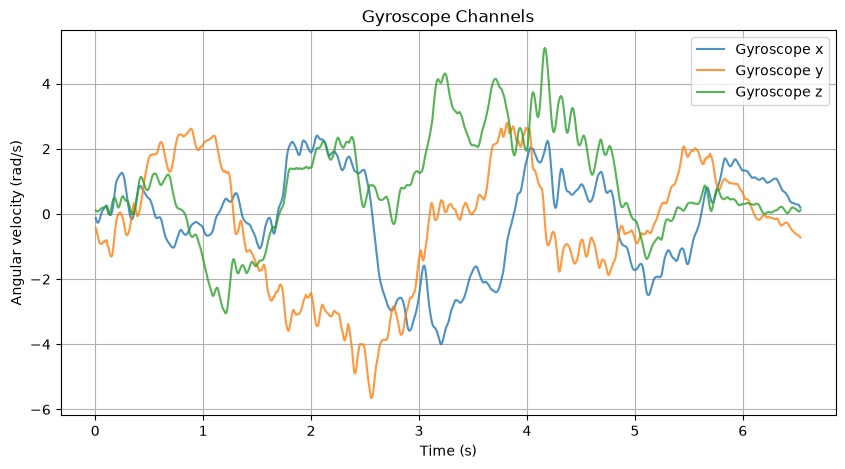

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
df = pd.read_csv("Raw Data.csv")

t = df["Time (s)"].values
gx = df["Gyroscope x (rad/s)"].values
gy = df["Gyroscope y (rad/s)"].values
gz = df["Gyroscope z (rad/s)"].values

plt.figure(figsize=(10, 5))
plt.plot(t, gx, label="Gyroscope x", alpha=0.8)
plt.plot(t, gy, label="Gyroscope y", alpha=0.8)
plt.plot(t, gz, label="Gyroscope z", alpha=0.8)
plt.title("Gyroscope Channels")
plt.xlabel("Time (s)")
plt.ylabel("Angular velocity (rad/s)")
plt.legend()
plt.grid(True)
plt.show()

<h3>Part 2</h3>


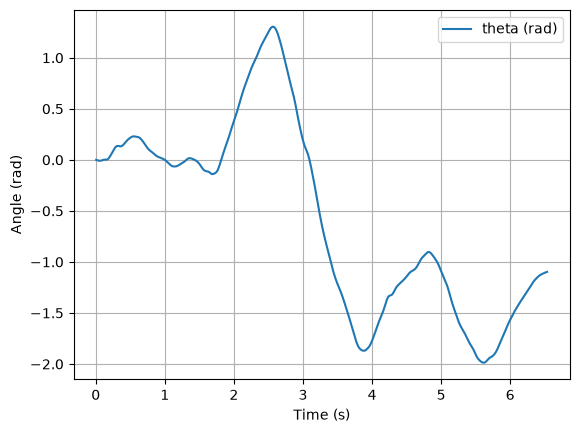

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
df = pd.read_csv("Raw Data.csv")

t = df["Time (s)"].values
omega = df["Gyroscope x (rad/s)"].values

def cumulative_trapezoid(y, t, initial=0.0):
    """Return the cumulative integral of y with the same length as y."""
    areas = 0.5*(y[1:] + y[:-1])*np.diff(t)
    return initial + np.concatenate(([0.0], np.cumsum(areas)))

theta = cumulative_trapezoid(omega, t)

plt.plot(t, theta, label="theta (rad)")
plt.xlabel("Time (s)")
plt.ylabel("Angle (rad)")
plt.legend()
plt.grid(True)
plt.show()



<h3>Part 3</h3>


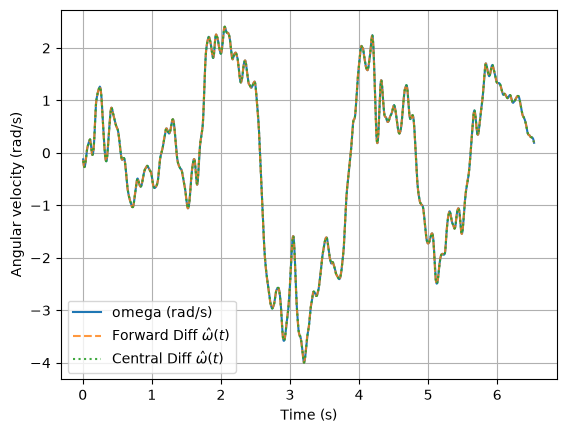

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
df = pd.read_csv("Raw Data.csv")

t = df["Time (s)"].values
omega = df["Gyroscope x (rad/s)"].values

h = np.mean(np.diff(t))

def cumulative_trapezoid(y, t, initial=0.0):
    """Return the cumulative integral of y with the same length as y."""
    areas = 0.5*(y[1:] + y[:-1])*np.diff(t)
    return initial + np.concatenate(([0.0], np.cumsum(areas)))

def forward_diff(y,h):
    y = np.asarray(y, dtype=float)
    return (y[1:] - y[:-1]) / h

def central_diff(y, h):
    y = np.asarray(y, dtype=float)
    return (y[2:] - y[:-2]) / (2 * h)


theta = cumulative_trapezoid(omega, t)
omega_forward = forward_diff(theta, h)
omega_central = central_diff(theta, h)



plt.plot(t, omega, label="omega (rad/s)")
plt.plot(t[:-1], omega_forward, "--", label="Forward Diff $\\hat{\\omega}(t)$", alpha=0.8,)
plt.plot(t[1:-1], omega_central, ":", label="Central Diff $\\hat{\\omega}(t)$", alpha=0.9,)
plt.xlabel("Time (s)")
plt.ylabel("Angular velocity (rad/s)")
plt.legend()
plt.grid(True)
plt.show()



The forward_diff and central_diff closely follows the original signal $\omega(t)$, showing that differentiation is able to recover the angular velocity. The graph shows how i rotated the phone in one direction then back again in the opposite direction with it going from 2 rad/s to -3 rad/s


# A derivative in the atmosphere
d(delta_M)/dt = E_CH4(t)/2.75 - delta_m/tau
where tau = 9.1 years
Rearrange => d(delta_M)/dt + delta_M = E_CH4(t)/2.75
so: E_CH4(t) = 2.75 \* (d(delta_M) + delta_M/tau)


In [33]:
tau = 9.1
h = 1

In [34]:
import numpy as np
with open("data/ch4_annual.dat", "r") as file:
    for i in range(10):
        print(file.readline())

data = np.loadtxt("data/ch4_annual.dat", skiprows=3)
print(data[:5])

# Source: NOAA Global Monitoring Laboratory, global mean atmospheric CH4 mole fraction (ppb).

# https://gml.noaa.gov/ccgg/trends_ch4/ (accessed 2026-07-30). cite{noaa_ch4}

Year	CH4_ppb

1984	1644.84

1985	1657.29

1986	1670.09

1987	1682.71

1988	1693.19

1989	1704.53

1990	1714.46

[[1984.   1644.84]
 [1985.   1657.29]
 [1986.   1670.09]
 [1987.   1682.71]
 [1988.   1693.19]]


In [36]:
year = data[:,0]
ch4 = data[:,1]
delta_M = ch4 - 700
print(delta_M[:5])

[944.84 957.29 970.09 982.71 993.19]


In [40]:
def methane_anomoly(t):
    return np.interp(t, year,delta_M)
dM_dt = central_diff(delta_M, h)
year_mid = year[1:-1]
print(dM_dt[:5])
print(year_mid[:5])
delta_M_mid = delta_M[1:-1]
E_CH4 = 2.75 * (dM_dt + delta_M_mid / tau)
print(E_CH4[:5])

[12.625 12.71  11.55  10.91  10.635]
[1985. 1986. 1987. 1988. 1989.]
[324.00968407 328.11156593 328.7353022  330.14233516 332.81300824]


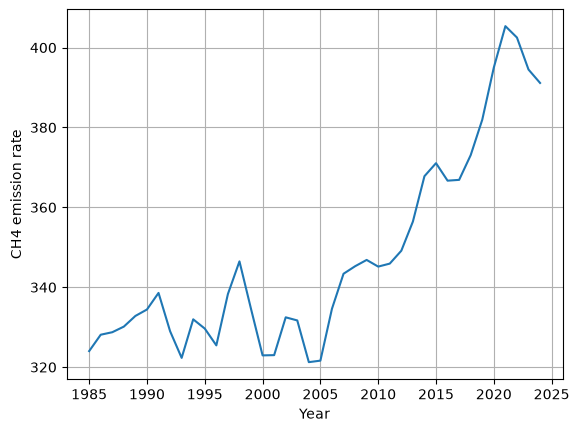

In [42]:
plt.plot(year_mid , E_CH4)
plt.xlabel("Year")
plt.ylabel("CH4 emission rate")
plt.grid()
plt.show()


The effective CH4 rate changes over time and has many fluctuations.